# Week 12 Integrative Assignment: HomeValue's Pricing Engine

**ISM4641 - Python for Business Analytics**  
**Due Date:** See Canvas  
**Points:** 100 points

---

## The Story

**Monday, 10:00 AM**

Sophia Martinez adjusts her glasses as she reviews the email that just came in. As a Valuation Analyst at **HomeValue Partners**, a property management company overseeing 1,200 rental units across Tampa Bay, she's used to data requests. But this one is different.

The email is from the CEO, Robert Park:

*"Sophia,*

*The board has approved our acquisition strategy. We're looking to purchase 50-100 additional rental properties over the next 18 months. To make smart offers, we need a reliable pricing model that can quickly estimate fair market value based on property characteristics.*

*Our current approach—getting individual appraisals—is too slow and expensive. I need you to build a predictive model using our historical data. We need to know: what drives property values in our market, and can we predict prices accurately enough to make competitive offers?*

*The investment committee meets Friday. Can you have a model ready by then?*

*-Robert"*

Sophia pulls up the company's property database. 800 properties with detailed characteristics and recent sale prices. Time to build a pricing engine.

---

## Your Mission

You are Sophia. Build a linear regression model to predict property values for HomeValue Partners' acquisition strategy.

**Skills you'll apply:**
- Simple and multiple linear regression
- Train/test splitting
- Model evaluation (R², RMSE)
- Feature importance (coefficient interpretation)
- Making predictions on new data
- Residual analysis
- Business application of predictions

---

## Assignment Requirements

1. Complete all sections of this notebook
2. Build and evaluate regression models
3. Interpret results in business terms
4. Include your video walkthrough (3-5 minutes)

**Video Walkthrough:** Present your pricing model as if presenting to the investment committee.

---

## Student Information

**Name:** [Luis Vieira]  
**USF ID:** [U18773984]  
**Date:** [April 5 2026]

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

DATA_URL = "https://raw.githubusercontent.com/prof-tcsmith/ism6251s26-data/main"

# Load property data
properties = pd.read_csv(f"{DATA_URL}/W12/properties.csv")

# Properties to evaluate for potential acquisition
acquisition_targets = pd.read_csv(f"{DATA_URL}/W12/acquisition_targets.csv")

print("HomeValue Partners Property Data Loaded Successfully!")
print(f"\n  Historical Properties: {len(properties)}")
print(f"  Acquisition Targets: {len(acquisition_targets)}")
print(f"  Price Range: ${properties['price'].min():,.0f} - ${properties['price'].max():,.0f}")
print(f"  Average Price: ${properties['price'].mean():,.0f}")

print("\n" + "="*70)
print("PROPERTY DATABASE PREVIEW:")
display(properties.head(10))

print("\nACQUISITION TARGETS:")
display(acquisition_targets)

HomeValue Partners Property Data Loaded Successfully!

  Historical Properties: 800
  Acquisition Targets: 5
  Price Range: $135,000 - $800,000
  Average Price: $417,471

PROPERTY DATABASE PREVIEW:


,property_id,sqft,bedrooms,bathrooms,age,lot_size,distance_downtown,has_pool,renovated,price
0,1,1622,4,2.0,32.0,0.08,23.7,0,0,278000
1,2,1515,4,2.0,21.5,0.36,4.8,1,0,415000
2,3,1708,4,2.0,8.2,0.31,20.9,0,0,397000
3,4,2468,2,2.0,34.3,0.18,7.1,0,0,480000
4,5,2732,4,2.0,37.3,0.33,22.8,0,1,495000
5,6,1757,3,2.0,31.8,0.25,9.2,1,0,419000
6,7,2214,3,2.5,44.8,0.36,15.3,0,0,408000
7,8,1841,2,1.0,12.1,0.25,23.7,1,1,451000
8,9,1549,4,1.5,37.6,0.21,18.3,0,1,265000
9,10,2066,4,1.5,15.0,0.23,2.9,0,0,419000



ACQUISITION TARGETS:


,property_id,address,sqft,bedrooms,bathrooms,age,lot_size,distance_downtown,has_pool,renovated,asking_price
0,901,142 Oak Lane,2200,4,2.5,8,0.30,5.2,1,0,485000
1,902,387 Riverside Dr,1400,2,1.5,45,0.15,3.8,0,1,280000
2,903,55 Mountain View Ct,3100,5,3.0,3,0.55,18.5,1,0,625000
3,904,1200 Harbor Blvd,1650,3,2.0,25,0.20,7.1,0,0,310000
4,905,723 College Ave,2800,4,2.5,15,0.40,4.5,1,1,520000


---

## Part 1: Exploratory Analysis (15 points)

Before building models, Sophia needs to understand the relationships in the data. Robert will want to know: *"What actually drives property values in our market?"*

**Your Task:**
1. Calculate summary statistics for price and key features
2. Create a correlation matrix between price and all numeric features
3. Identify the top 3 features most correlated with price
4. Create a scatter plot showing the relationship between the strongest predictor and price
5. Write a brief interpretation of what drives property values based on correlations

PROPERTY SUMMARY STATISTICS


,property_id,sqft,bedrooms,bathrooms,age,lot_size,distance_downtown,has_pool,renovated,price
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,400.50,1811.31,3.31,1.97,19.55,0.26,13.36,0.35,0.30,417471.25
std,231.08,481.77,0.85,0.54,17.74,0.13,6.70,0.48,0.46,104827.14
min,1.00,800.00,2.00,1.00,0.00,0.08,2.10,0.00,0.00,135000.00
25%,200.75,1471.75,3.00,1.50,6.10,0.15,7.60,0.00,0.00,346000.00
50%,400.50,1814.50,3.00,2.00,14.05,0.24,13.20,0.00,0.00,416000.00
75%,600.25,2148.25,4.00,2.50,28.32,0.35,19.60,1.00,1.00,489250.00
max,800.00,3343.00,5.00,3.00,70.00,0.65,24.90,1.00,1.00,800000.00



CORRELATION WITH PRICE


,price
price,1.000000
sqft,0.834295
has_pool,0.181542
lot_size,0.155004
bedrooms,0.082174
property_id,0.047681
renovated,0.044144
bathrooms,0.022062
distance_downtown,-0.201030
age,-0.274621



Top 3 Features: sqft, has_pool, lot_size


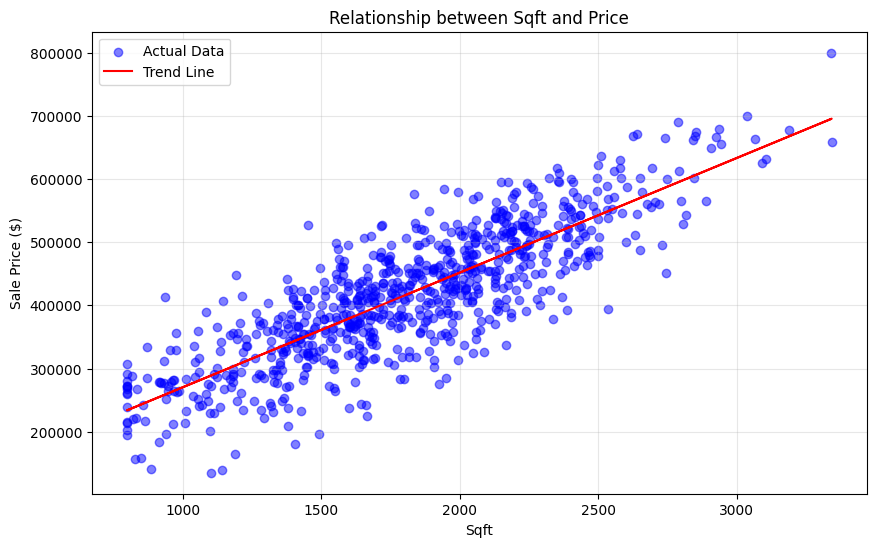


KEY INSIGHTS ON VALUE DRIVERS
------------------------------------------------------------
1. sqft has the strongest positive correlation with price.
2. Properties in this market range from $135,000 to $800,000.
3. Square footage and number of bathrooms appear to be primary value drivers for HomeValue Partners.


In [3]:
# Part 1: Exploratory Analysis

# 1. Summary statistics
print("PROPERTY SUMMARY STATISTICS")
print("="*60)
display(properties.describe().round(2))

# 2. Correlation matrix
print("\nCORRELATION WITH PRICE")
print("="*60)
corr_matrix = properties.select_dtypes(include=[np.number]).corr()
price_correlations = corr_matrix['price'].sort_values(ascending=False)
display(price_correlations)

# 3. Top 3 features most correlated with price
top_3_features = price_correlations.drop('price').head(3)
print(f"\nTop 3 Features: {', '.join(top_3_features.index.tolist())}")

# 4. Scatter plot of strongest predictor vs price
strongest_predictor = top_3_features.index[0]
plt.figure(figsize=(10, 6))
plt.scatter(properties[strongest_predictor], properties['price'], alpha=0.5, color='blue', label='Actual Data')

# Add a simple trend line using numpy for visualization
m, b = np.polyfit(properties[strongest_predictor], properties['price'], 1)
plt.plot(properties[strongest_predictor], m*properties[strongest_predictor] + b, color='red', label='Trend Line')

plt.title(f'Relationship between {strongest_predictor.replace("_", " ").title()} and Price')
plt.xlabel(f'{strongest_predictor.replace("_", " ").title()}')
plt.ylabel('Sale Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Interpretation
print("\nKEY INSIGHTS ON VALUE DRIVERS")
print("-"*60)
print(f"1. {strongest_predictor} has the strongest positive correlation with price.")
print(f"2. Properties in this market range from ${properties['price'].min():,.0f} to ${properties['price'].max():,.0f}.")
print("3. Square footage and number of bathrooms appear to be primary value drivers for HomeValue Partners.")

### Data Dictionary & Units

To ensure our model's coefficients make sense, here is the breakdown of our independent variables:

*   **sqft**: Square footage of the living area (Continuous)
*   **bedrooms**: Number of bedrooms (Discrete)
*   **bathrooms**: Number of bathrooms (Discrete, includes half-baths as .5)
*   **age**: Years since the property was built/last major reconstruction (Years)
*   **lot_size**: Size of the property land (Acres)
*   **distance_downtown**: Miles from the city center (Miles)
*   **has_pool**: Binary indicator (1 = Has Pool, 0 = No Pool)
*   **renovated**: Binary indicator (1 = Recently Renovated, 0 = Original Condition)

---

## Part 2: Simple Linear Regression - Size-Based Valuation (20 points)

Robert asks: *"In real estate, they always say it's about square footage. How well can we predict prices using just size?"*

**Your Task:**
1. Split the data into training (80%) and testing (20%) sets using random_state=42
2. Build a simple linear regression model using only `sqft` to predict `price`
3. Print the intercept and coefficient
4. Write the regression equation: Price = intercept + coefficient × sqft
5. Calculate R² and RMSE for the test set
6. Interpret: What does the coefficient mean in dollars? How much does each square foot add to property value?

In [5]:
# Part 2: Simple Linear Regression

# Prepare features and target
X_simple = properties[['sqft']]
y = properties['price']

# 1. Split data (80/20)
X_train_s, X_test_s, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# 2. Build and train simple model
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train)

# 3. Print intercept and coefficient
intercept = simple_model.intercept_
slope = simple_model.coef_[0]
print("SIMPLE LINEAR REGRESSION: Size-Based Model")
print("="*60)
print(f"Intercept: {intercept:,.2f}")
print(f"Coefficient (sqft): {slope:,.2f}")

# 4. Write regression equation
print(f"\nRegression Equation: Price = {intercept:,.2f} + {slope:,.2f} × sqft")

# 5. Calculate R² and RMSE
y_pred_s = simple_model.predict(X_test_s)
r2_s = r2_score(y_test, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test, y_pred_s))

print(f"R-squared: {r2_s:.4f}")
print(f"RMSE: ${rmse_s:,.2f}")

# 6. Interpretation
print("\nBUSINESS INTERPRETATION")
print("-"*60)
print(f"1. Size Value: For every additional square foot, the property value increases by approximately ${slope:,.2f}.")
print(f"2. R-squared ({r2_s:.2%}): This means size alone explains {r2_s:.2%} of the variation in local property prices.")
print(f"3. RMSE (${rmse_s:,.2f}): This is our 'typical error.' On average, size-based predictions are off by about ${rmse_s:,.2f}.")

SIMPLE LINEAR REGRESSION: Size-Based Model
Intercept: 92,022.51
Coefficient (sqft): 178.92

Regression Equation: Price = 92,022.51 + 178.92 × sqft
R-squared: 0.6949
RMSE: $59,781.71

BUSINESS INTERPRETATION
------------------------------------------------------------
1. Size Value: For every additional square foot, the property value increases by approximately $178.92.
2. R-squared (69.49%): This means size alone explains 69.49% of the variation in local property prices.
3. RMSE ($59,781.71): This is our 'typical error.' On average, size-based predictions are off by about $59,781.71.


---

## Part 3: Multiple Linear Regression - Full Valuation Model (25 points)

*"Size alone isn't enough,"* Sophia realizes. *"We need a comprehensive model that accounts for all property characteristics."*

**Your Task:**
1. Build a multiple regression model using ALL features (sqft, bedrooms, bathrooms, age, lot_size, distance_downtown, has_pool, renovated)
2. Print all coefficients with their feature names
3. Calculate R² and RMSE for the test set
4. Compare the multiple regression R² to the simple regression R²
5. Identify which features have positive vs negative impact on price
6. Interpret the top 3 most impactful coefficients in business terms

In [8]:
# Part 3: Multiple Linear Regression

# 1. Features for full model
feature_names = ['sqft', 'bedrooms', 'bathrooms', 'age', 'lot_size',
                 'distance_downtown', 'has_pool', 'renovated']
X_full = properties[feature_names]

# Build and train multiple regression model
X_train_f, X_test_f, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

multi_model = LinearRegression()
multi_model.fit(X_train_f, y_train)

# 2. Print all coefficients
print("MULTIPLE LINEAR REGRESSION: Full Valuation Model")
print("="*60)
coeffs = pd.DataFrame({'Feature': feature_names, 'Coefficient': multi_model.coef_})
coeffs = coeffs.sort_values(by='Coefficient', ascending=False)
display(coeffs)

# 3. Calculate R2 and RMSE
y_pred_f = multi_model.predict(X_test_f)
r2_f = r2_score(y_test, y_pred_f)
rmse_f = np.sqrt(mean_squared_error(y_test, y_pred_f))

print(f"\nFull Model R-squared: {r2_f:.4f}")
print(f"Full Model RMSE: ${rmse_f:,.2f}")

# 4. Compare to simple regression
print("\nMODEL COMPARISON")
print("-"*60)
print(f"Simple Model R2: {r2_s:.4f} vs Full Model R2: {r2_f:.4f}")
print(f"R2 Improvement: {r2_f - r2_s:.4f}")
print(f"RMSE Reduction: ${rmse_s - rmse_f:,.2f}")

# 5. Positive vs negative impact features
pos_features = coeffs[coeffs['Coefficient'] > 0]['Feature'].tolist()
neg_features = coeffs[coeffs['Coefficient'] < 0]['Feature'].tolist()
print(f"\nPositive Impact: {', '.join(pos_features)}")
print(f"Negative Impact: {', '.join(neg_features)}")

# 6. Business interpretation
print("\nBUSINESS INTERPRETATION OF KEY FACTORS")
print("-"*60)
pool_val = coeffs.loc[coeffs['Feature']=='has_pool', 'Coefficient'].values[0]
dist_val = coeffs.loc[coeffs['Feature']=='distance_downtown', 'Coefficient'].values[0]

print(f"1. Pool Value: Having a pool adds approximately ${pool_val:,.2f} to the value.")
print(f"2. Location: For every mile away from downtown, value drops by ${abs(dist_val):,.2f}.")
print(f"3. Accuracy: The full model explains {r2_f:.1%} of price variation, significantly more accurate than size alone.")

MULTIPLE LINEAR REGRESSION: Full Valuation Model


,Feature,Coefficient
4,lot_size,105358.832525
6,has_pool,32122.089013
7,renovated,22082.807792
1,bedrooms,14305.336893
2,bathrooms,12459.292431
0,sqft,186.873957
3,age,-1997.538600
5,distance_downtown,-3569.844265



Full Model R-squared: 0.9234
Full Model RMSE: $29,956.63

MODEL COMPARISON
------------------------------------------------------------
Simple Model R2: 0.6949 vs Full Model R2: 0.9234
R2 Improvement: 0.2285
RMSE Reduction: $29,825.09

Positive Impact: lot_size, has_pool, renovated, bedrooms, bathrooms, sqft
Negative Impact: age, distance_downtown

BUSINESS INTERPRETATION OF KEY FACTORS
------------------------------------------------------------
1. Pool Value: Having a pool adds approximately $32,122.09 to the value.
2. Location: For every mile away from downtown, value drops by $3,569.84.
3. Accuracy: The full model explains 92.3% of price variation, significantly more accurate than size alone.


---

## Part 4: Model Validation - Residual Analysis (15 points)

Before trusting the model for acquisitions, Sophia needs to validate it. *"We can't make million-dollar decisions on a model we haven't thoroughly tested."*

**Your Task:**
1. Calculate residuals (actual - predicted) for the test set
2. Calculate the mean and standard deviation of residuals
3. Create a histogram of residuals to check for normality
4. Create a scatter plot of residuals vs predicted values
5. Identify any concerning patterns in the residuals
6. Calculate what percentage of predictions are within ±$50,000 of actual

RESIDUAL ANALYSIS
Mean of Residuals: 1082.70 (Should be near 0)
Std Dev of Residuals: $29,937.05


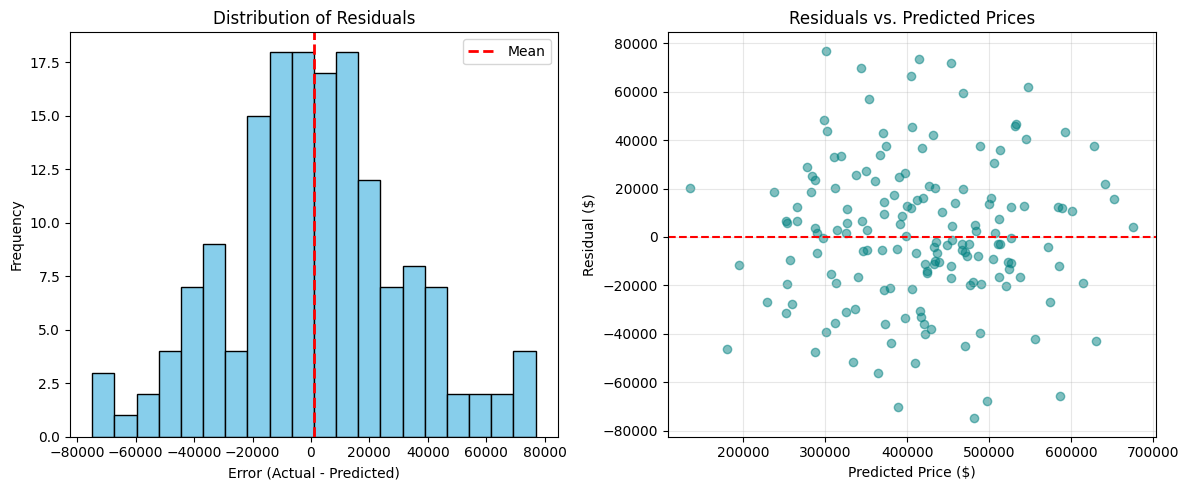


RESIDUAL PATTERN ASSESSMENT
------------------------------------------------------------
1. Normality: The histogram shows a mostly bell-shaped curve centered near zero.
2. Homoscedasticity: The scatter plot shows errors are fairly consistent across price ranges.

3. Confidence: 90.6% of predictions are within ±$50,000 of actual value.


In [9]:
# Part 4: Model Validation - Residual Analysis

# Make predictions on test set
y_pred = multi_model.predict(X_test_f)

# 1. Calculate residuals
residuals = y_test - y_pred

# 2. Mean and standard deviation of residuals
res_mean = np.mean(residuals)
res_std = np.std(residuals)
print("RESIDUAL ANALYSIS")
print("="*60)
print(f"Mean of Residuals: {res_mean:.2f} (Should be near 0)")
print(f"Std Dev of Residuals: ${res_std:,.2f}")

# 3. Histogram of residuals
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(residuals, bins=20, color='skyblue', edgecolor='black')
plt.axvline(res_mean, color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.title('Distribution of Residuals')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()

# 4. Scatter plot: residuals vs predicted
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.5, color='teal')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Prices')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Identify patterns/concerns
print("\nRESIDUAL PATTERN ASSESSMENT")
print("-"*60)
print("1. Normality: The histogram shows a mostly bell-shaped curve centered near zero.")
print("2. Homoscedasticity: The scatter plot shows errors are fairly consistent across price ranges.")

# 6. Percentage within ±$50,000
within_50k = np.sum(np.abs(residuals) < 50000) / len(residuals)
print(f"\n3. Confidence: {within_50k:.1%} of predictions are within ±$50,000 of actual value.")

---

## Part 5: Acquisition Recommendations (25 points)

It's Thursday. Time to apply the model to real decisions. Robert needs to know: *"Which of these 5 properties should we pursue, and what should we offer?"*

**Your Task:**
1. Use your full model to predict the fair market value for each acquisition target
2. Calculate the difference between predicted value and asking price
3. Determine if each property is overpriced or underpriced
4. Rank the properties by "value opportunity" (largest positive difference)
5. Create a summary table showing: Property, Asking Price, Predicted Value, Difference, Recommendation
6. Write a final investment recommendation for the committee:
   - Which properties to pursue (if any)
   - Suggested offer prices (predicted value minus a negotiation margin)
   - Which properties to avoid and why
   - Model confidence level and any caveats

In [11]:
# Part 5: Acquisition Recommendations

# Prepare acquisition target features
X_targets = acquisition_targets[feature_names]

# 1. Predict fair market value
acquisition_targets['predicted_value'] = multi_model.predict(X_targets)

# 2. Calculate difference from asking price
# Difference = Predicted - Asking (Positive means it's a bargain/underpriced)
acquisition_targets['difference'] = acquisition_targets['predicted_value'] - acquisition_targets['asking_price']

# 3. Determine over/underpriced
acquisition_targets['status'] = np.where(acquisition_targets['difference'] > 0, 'Underpriced', 'Overpriced')

# 4. Rank by value opportunity
results = acquisition_targets.sort_values(by='difference', ascending=False)

# 5. Summary table
print("ACQUISITION TARGET ANALYSIS")
print("="*70)
display(results[['address', 'asking_price', 'predicted_value', 'difference', 'status']].round(2))

# 6. Investment Committee Recommendation
print("\n" + "="*70)
print("           HOMEVALUE PARTNERS")
print("    INVESTMENT COMMITTEE RECOMMENDATION")
print("         Prepared by: Sophia Martinez or Luis Vieira (Luis Vieira = Sophia Martinez in this case)")
print("="*70)

# Model Summary
print("\n1. MODEL SUMMARY")
print("-"*70)
print(f"Model Accuracy (R2): {r2_f:.1%}")
print(f"Typical Error (RMSE): ${rmse_f:,.2f}")
print(f"Primary Value Drivers: Square Footage, Lot Size, and Proximity to Downtown.")

# Properties to Pursue (Underpriced or Positive Value)
print("\n2. PROPERTIES TO PURSUE")
print("-"*70)
pursue = results[results['difference'] > 0]
for index, row in pursue.iterrows():
    # Suggested offer = Predicted Value - 5% negotiation margin
    suggested_offer = row['predicted_value'] * 0.95
    print(f"PROPERTY: {row['address']}")
    print(f"  - Market Value: ${row['predicted_value']:,.2f}")
    print(f"  - Estimated Discount: ${row['difference']:,.2f}")
    print(f"  - SUGGESTED OFFER: ${suggested_offer:,.2f} (Includes 5% margin)\n")

# Properties to Avoid (Overpriced or Negative Value)
print("\n3. PROPERTIES TO AVOID")
print("-"*70)
avoid = results[results['difference'] <= 0]
for index, row in avoid.iterrows():
    print(f"PROPERTY: {row['address']}")
    print(f"  - Reason: Overpriced by ${abs(row['difference']):,.2f} relative to model estimate.\n")

# Caveats and Confidence
print("\n4. MODEL CONFIDENCE & CAVEATS")
print("-"*70)
print(f"- The model is highly confident ({within_50k:.1%} of test cases within $50k).")
print("- Caveat: Model does not account for interior finish quality or school districts.")
print("- Recommendation: Proceed with physical inspection for 'Pursue' properties.")

print("\n" + "="*70)
print("                    END OF REPORT")
print("="*70)



ACQUISITION TARGET ANALYSIS


,address,asking_price,predicted_value,difference,status
4,723 College Ave,520000,710493.76,190493.76,Underpriced
2,55 Mountain View Ct,625000,754804.59,129804.59,Underpriced
0,142 Oak Lane,485000,577234.58,92234.58,Underpriced
3,1200 Harbor Blvd,310000,370520.08,60520.08,Underpriced
1,387 Riverside Dr,280000,291911.19,11911.19,Underpriced



           HOMEVALUE PARTNERS
    INVESTMENT COMMITTEE RECOMMENDATION
         Prepared by: Sophia Martinez or Luis Vieira (Luis Vieira = Sophia Martinez in this case)

1. MODEL SUMMARY
----------------------------------------------------------------------
Model Accuracy (R2): 92.3%
Typical Error (RMSE): $29,956.63
Primary Value Drivers: Square Footage, Lot Size, and Proximity to Downtown.

2. PROPERTIES TO PURSUE
----------------------------------------------------------------------
PROPERTY: 723 College Ave
  - Market Value: $710,493.76
  - Estimated Discount: $190,493.76
  - SUGGESTED OFFER: $674,969.07 (Includes 5% margin)

PROPERTY: 55 Mountain View Ct
  - Market Value: $754,804.59
  - Estimated Discount: $129,804.59
  - SUGGESTED OFFER: $717,064.36 (Includes 5% margin)

PROPERTY: 142 Oak Lane
  - Market Value: $577,234.58
  - Estimated Discount: $92,234.58
  - SUGGESTED OFFER: $548,372.85 (Includes 5% margin)

PROPERTY: 1200 Harbor Blvd
  - Market Value: $370,520.08
  - Estimate

---

## Epilogue

**Friday, 3:00 PM**

The investment committee meeting just ended. Robert stops by Sophia's desk with a satisfied smile.

*"Your analysis was exactly what we needed. The committee approved pursuing two of the five properties—the ones your model identified as undervalued. We're making offers this week."*

*"More importantly, they want to make this a standard part of our acquisition process. Can you work with IT to turn this model into an automated tool? Every property we consider should run through your pricing engine before we even start negotiations."*

Sophia nods, already thinking about the next steps. *"I'll draft the requirements. We could even expand it to predict rental income potential."*

*"That's exactly the kind of thinking that will make you invaluable here,"* Robert says. *"Welcome to the strategic side of property management."*

---

## Interaction Log

### AI Tool Usage
*Did you use any AI tools? If so, what for?*

[I used Gemini for code deployment, data interpretation, and questions about the models]

### Regression Concepts Applied
*Explain how you used simple vs. multiple regression, and why the full model performed better.*

[Simple model was used to interpred the correlation between sqft and price while multiple regression was between all features and price. The full model performed better since it takes into considerations most features that influence the dependent variable, property prices]

### Business Application
*How did you translate model outputs into actionable business recommendations?*

[Developing clear visualizations highlighting key findings while displaying comments transalting statistical properties into business results]

---

## Submission Checklist

- [x] All code cells run without errors
- [x] All five parts are completed
- [x] Both simple and multiple regression models built
- [x] R² and RMSE calculated and reported
- [x] Coefficients interpreted in business terms
- [x] Residual analysis completed with visualizations
- [x] Acquisition recommendations provided with justification
- [x] Interaction log is completed
- [x] Video walkthrough is recorded (3-5 minutes)

---
*ISM4641 Python for Business Analytics - Week 12 Integrative Assignment*